# Wildfire Detection from Satellite Imagery
*Binary classification using Logistic Regression, LDA, and QDA on MODIS-derived features*

**Author:** Joseph Montalto

## Project Overview

Wildfires cause billions of dollars in damage each year and threaten both ecosystems and human life. Early detection from satellite imagery can significantly improve response times. In this project, I use a published wildfire dataset to build and compare binary classifiers that predict whether a geographic region has experienced a wildfire based on three satellite-derived features.

**Dataset:** The data comes from the journal article *"Predictive modeling of wildfires: A new dataset and machine learning approach"* by Sayad, Mousannif, and Al Moatassime. Each observation represents a geographic area captured by MODIS (Moderate Resolution Imaging Spectroradiometer) satellite instruments, with the following features:

| Feature | Description |
|---|---|
| **NDVI** | Normalized Difference Vegetation Index — measures vegetation greenness/health (higher = denser vegetation) |
| **LST** | Land Surface Temperature — thermal reading of the ground surface (in scaled Kelvin units) |
| **THERMAL_ANOMALIES** | Count/intensity of abnormal thermal activity detected by the satellite sensor |
| **CLASS** | Ground-truth label: `fire` or `no_fire` |

**Approach:** I train and evaluate three families of classifiers — Logistic Regression, Linear Discriminant Analysis (LDA), and Quadratic Discriminant Analysis (QDA) — and compare them using accuracy, sensitivity, specificity, precision, and ROC/AUC analysis. Because the dataset is imbalanced (~77% no-fire), I apply SMOTE oversampling and class-weight balancing to ensure models learn to detect the minority (fire) class.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import seaborn as sns

from IPython.display import Image, display

from scipy.stats import norm
from scipy.stats import multivariate_normal

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn import metrics

from imblearn.over_sampling import SMOTE

import statsmodels.api as sm

## 1. Data Exploration

The dataset contains satellite observations labeled as either `fire` or `no_fire`. Let's load the data and explore its structure.

In [2]:
df_WildFires = pd.read_csv("/cluster/tufts/c26sp1cee0132/shared/DataLab_4/WildFires_DataSet.csv") #If the csv file is within the same folder as this Jupyter notebook.
df_WildFires.head()

,NDVI,LST,THERMAL_ANOMALIES,CLASS
0,0.506782,14584.27273,4.692308,no_fire
1,0.522150,14655.83333,5.000000,no_fire
2,0.682284,14780.00000,5.000000,fire
3,0.120046,13298.50000,3.500000,no_fire
4,0.568734,14743.00000,5.000000,no_fire


Each feature captures a different aspect of the satellite observation:

- **NDVI** is a satellite-based index measuring vegetation greenness. Healthy, dense vegetation yields values closer to 1, while bare soil or burned areas yield lower values.
- **LST** is the land surface temperature derived from thermal infrared bands. Higher values indicate hotter ground surfaces.
- **THERMAL_ANOMALIES** quantifies abnormal thermal activity — a proxy for active fire intensity.
- **CLASS** is the ground-truth wildfire label (`fire` or `no_fire`), validated against historical fire records.

In [3]:
classes = pd.unique(df_WildFires["CLASS"])
print("Number of classes:", len(classes))
print("Classes:", classes)

print("\nRows per class:")
print(df_WildFires["CLASS"].value_counts())

Number of classes: 2
Classes: <ArrowStringArray>
['no_fire', 'fire']
Length: 2, dtype: str

Rows per class:
CLASS
no_fire    1327
fire        386
Name: count, dtype: int64


Before building classifiers, let's compare the average feature values across the two classes:

In [4]:
df_WildFires.groupby("CLASS").mean()

,NDVI,LST,THERMAL_ANOMALIES
CLASS,,,
fire,0.533801,14818.157752,4.762614
no_fire,0.562025,14565.976683,4.649479


**Observations from the class means:**
- The fire class has a slightly *lower* average NDVI (0.534 vs. 0.562), consistent with vegetation damage or loss.
- Fire regions show a *higher* average LST (14,818 vs. 14,566), as expected — active fires and recently burned land radiate more heat.
- THERMAL_ANOMALIES is marginally higher for fire regions (4.76 vs. 4.65), indicating slightly elevated thermal activity.

The differences are modest, which suggests no single feature will be a strong standalone predictor — multivariate approaches should perform better.

### Correlation Between Features

High correlations between predictive features can cause instability in some classifiers (e.g., logistic regression). Let's examine the pairwise correlations:

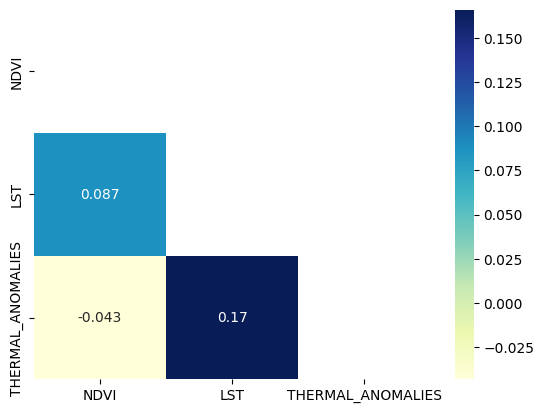

In [5]:
# Isolate the predictive variables (i.e. remove the response variable)
X = df_WildFires.drop(["CLASS"], axis = 1)

# Determine the correlations between the predictive variables
corr = X.corr()
   
# The correlation matrix will have values of one along the diagonal (a predictive variable
# correlated to itself). Information above this diagonal is duplicated below the diagonal.
# For example the correlation between LST and NDVI is the same as the correlation between
# NDVI and LST. Because of this, it is customary to only show half of the correlation matrix
# and mask the duplicate information.
mask = np.zeros_like(corr)
mask[np.triu_indices_from(mask)] = True

# Construct a heatmap of the correlation matrix
# Seaborn is a python package for plotting, similar to matplotlib. 
# I personally prefer using seaborn for constructing heatmaps because a linear scale showing
# the colors used is automatically shown to the right of the heatmap.
# Note "annot = True" shows the correlation coefficient in each cell
sns.heatmap(corr, 
        xticklabels=corr.columns,
        yticklabels=corr.columns,
        mask = mask, cmap="YlGnBu",
        annot=True)
plt.show()

A pair plot lets us visualize the joint distributions of each feature pair, colored by class:

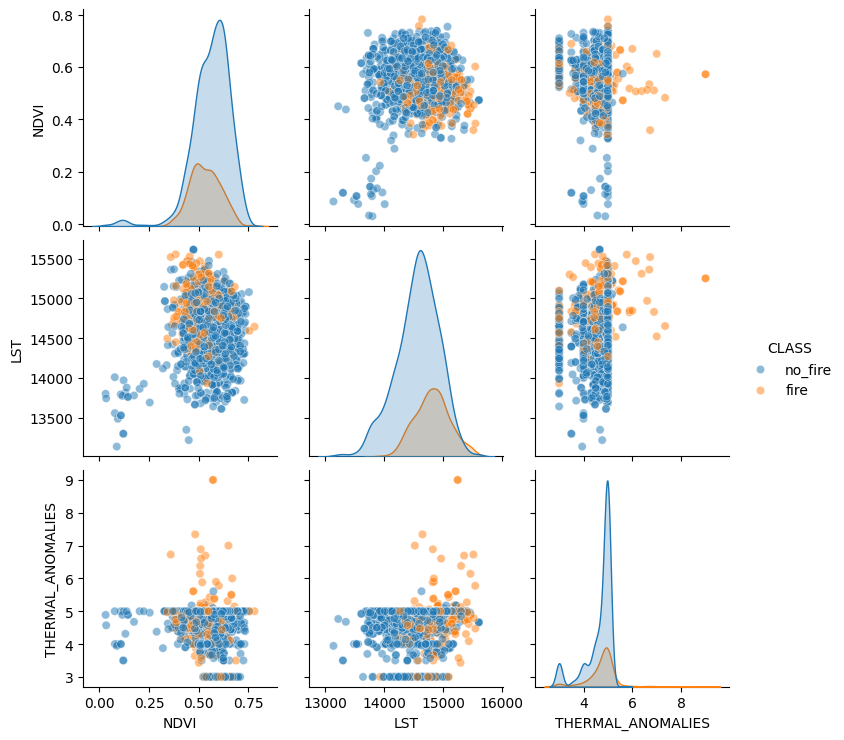

In [6]:
sns.pairplot(df_WildFires,hue="CLASS", plot_kws=dict(alpha=0.5))

plt.show()

The correlations between NDVI, LST, and THERMAL_ANOMALIES are relatively weak (all below 0.25 in magnitude). This means multicollinearity is not a concern for our classifiers, and each feature contributes relatively independent information to the models.

### Label Encoding

To use the labels in numerical models, we encode `no_fire` as **0** and `fire` as **1**:

In [7]:
# Replace qualitative values with integers representing categories.
mapping = {'no_fire': 0, 'fire': 1}
df_WildFires['CLASS'] = df_WildFires['CLASS'].map(pd.Series(mapping))

# Isolate the response variable, y
y = df_WildFires["CLASS"]

In [8]:
df_WildFires

,NDVI,LST,THERMAL_ANOMALIES,CLASS
0,0.506782,14584.27273,4.692308,0
1,0.522150,14655.83333,5.000000,0
2,0.682284,14780.00000,5.000000,1
3,0.120046,13298.50000,3.500000,0
4,0.568734,14743.00000,5.000000,0
...,...,...,...,...
1708,0.621721,14406.00000,5.000000,0
1709,0.709715,14330.40000,4.851852,0
1710,0.613000,14751.50000,3.000000,1
1711,0.614471,13611.00000,4.921053,0


### Train/Test Split

We split the data 80/20 into training and testing sets. The training set is used to fit models; the held-out test set evaluates generalization performance.

In [9]:
df_train, df_test = train_test_split(df_WildFires,
                                    test_size = 0.2, # 20% of the data is in the test set and 80% of the data is in the training set
                                    random_state = 0)# To ensure consistency in answer across students, we will randomly select the same observations

## 2. Baseline: Null Classifier

A null (majority-class) classifier always predicts the most common class. It sets the performance floor — any useful model must outperform it.

In [10]:
# Determine majority class from training data
majority_class = df_train['CLASS'].mode()[0]
print('Majority class in training set:', majority_class)

# Trivial null classifier: predict majority class for every test example
y_pred_null = np.full(len(df_test), majority_class)

# Evaluate on testing set
null_accuracy = metrics.accuracy_score(df_test['CLASS'], y_pred_null)
print('Null classifier test accuracy: %.3f' % null_accuracy)

# # show confusion matrix
# null_cnf_matrix = metrics.confusion_matrix(df_test['CLASS'], y_pred_null)
# print('Null classifier confusion matrix:')
# print(null_cnf_matrix)


Majority class in training set: 0
Null classifier test accuracy: 0.746


## 3. Logistic Regression

### 3.1 Simple Logistic Regression (Single Feature)

We start with a simple logistic regression using only **LST** (Land Surface Temperature) as the predictor. This establishes how well a single satellite measurement separates the two classes.

Training the unbalanced simple logistic regression on LST and visualizing the fitted sigmoid curve against the training data:

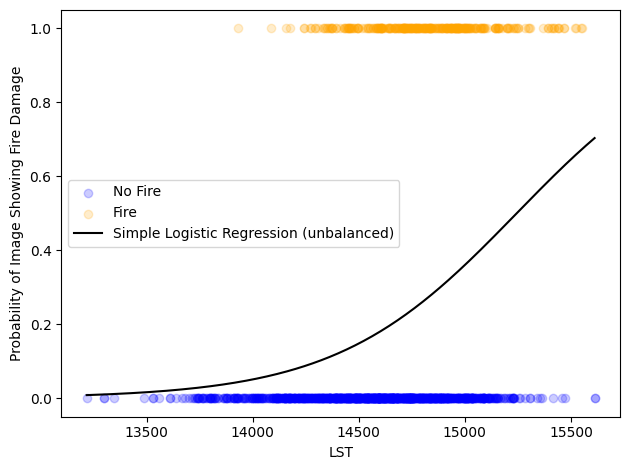

In [11]:
# Define LST as our single feature of interest
variable_of_interest = 'LST'

# Train a logistic regression model using the training data set
simple_logreg_unbalanced = LogisticRegression()
simple_logreg_unbalanced.fit(df_train[[variable_of_interest]], df_train['CLASS'])

# Generate a range of values for plotting the logistic regression curve
X_range = np.linspace(df_train[variable_of_interest].min(), df_train[variable_of_interest].max(), 300)
X_range_df = pd.DataFrame(X_range, columns=[variable_of_interest])

# Use the fitted simple logistic regression to display the probability of 
# an image showing fire damage as a function of the variable of interest
probs = simple_logreg_unbalanced.predict_proba(X_range_df)[:, 1]

# Plot using the corrected DataFrame
#plt.figure(figsize=(10, 6))
plt.scatter(df_train[df_train.CLASS == 0][variable_of_interest], df_train[df_train.CLASS == 0]['CLASS'], color='blue', label='No Fire', alpha=0.2)
plt.scatter(df_train[df_train.CLASS == 1][variable_of_interest], df_train[df_train.CLASS == 1]['CLASS'], color='orange', label='Fire', alpha=0.2)
plt.plot(X_range_df[variable_of_interest], probs, label='Simple Logistic Regression (unbalanced)', color='black')
plt.xlabel(variable_of_interest)
plt.ylabel('Probability of Image Showing Fire Damage')
plt.legend()
plt.tight_layout()
plt.show()

Evaluating on the held-out test set:

In [12]:
# Use the simple logistic model to predict the class based on only the variable of interest
y_pred = simple_logreg_unbalanced.predict(df_test[[variable_of_interest]])

# Compute model accuracy
accuracy = metrics.accuracy_score(df_test['CLASS'], y_pred)
print('The accuracy of this model is %.3f' %accuracy)

# Create the confusion matrix
cnf_matrix = metrics.confusion_matrix(df_test['CLASS'], y_pred)
print('The confusion matrix is:')
print(cnf_matrix)

The accuracy of this model is 0.743
The confusion matrix is:
[[247   9]
 [ 79   8]]


**Why does simple logistic regression underperform the null classifier?**

The dataset is heavily imbalanced (~77% no-fire). An unbalanced model learns to maximize overall accuracy by predicting the majority class almost exclusively, resulting in very low sensitivity (ability to detect actual fires). The null classifier achieves the same effect by design — so an unbalanced logistic regression on a single weak feature offers no improvement.

### Understanding the Confusion Matrix

The confusion matrix breaks down predictions into four categories. For wildfire detection, the critical cell is the **False Negative (FN)** — fires the model fails to detect — since missed fires have the most severe real-world consequences.

The layout is:

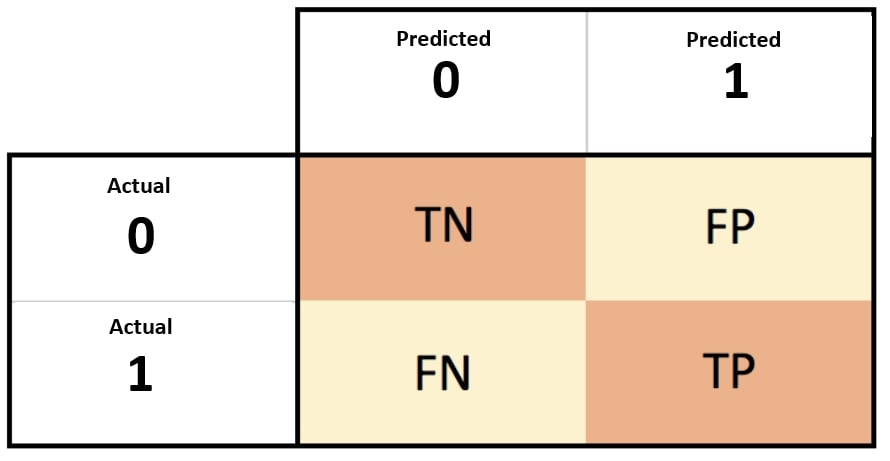

In [13]:
# Confusion matrix layout reference
# (Image pre-rendered from training materials)
display(Image(filename='/cluster/tufts/c26sp1cee0132/shared/DataLab_4/confusion_matrix.jpg'))

In [14]:
def classification_metrics(cnf_matrix):
    """Extract accuracy, specificity, sensitivity, and precision from a confusion matrix."""
    TN = cnf_matrix[0][0]
    FN = cnf_matrix[1][0]
    FP = cnf_matrix[0][1]
    TP = cnf_matrix[1][1]
    N  = TN + FP
    P  = TP + FN
    P_star = TP + FP

    accuracy    = (TN + TP)/(N+P)
    specificity = (TN) / (TN + FP)
    sensitivity = (TP) / (TP + FN)
    precision   = (TP) / (TP + FP)
    
    return accuracy, specificity, sensitivity, precision

In [15]:
[accuracy_LR_simple_unbalanced, specificity_LR_simple_unbalanced, sensitivity_LR_simple_unbalanced, precision_LR_simple_unbalanced] = classification_metrics(cnf_matrix)
print('Accuracy:    %.3f' %accuracy_LR_simple_unbalanced)
print('Specificity: %.3f' %specificity_LR_simple_unbalanced)
print('Sensitivity: %.3f' %sensitivity_LR_simple_unbalanced)
print('Precision:   %.3f' %precision_LR_simple_unbalanced)

Accuracy:    0.743
Specificity: 0.965
Sensitivity: 0.092
Precision:   0.471


### Addressing Class Imbalance

Scikit-learn's `class_weight='balanced'` adjusts the loss function to penalize misclassification of the minority class more heavily, effectively rebalancing the training signal:

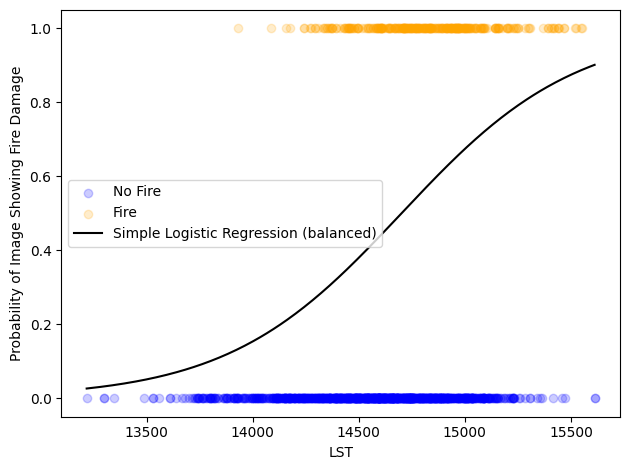

In [16]:
# Train a BALANCED simple logistic regression model using the training data set
simple_logreg = LogisticRegression(class_weight = 'balanced') #NOTE: This is the only line of code that changed, other than changing 'simple_logreg_unbalanced' to 'simple_logreg'
simple_logreg.fit(df_train[[variable_of_interest]], df_train['CLASS'])

# Generate a range of values for plotting the logistic regression curve
X_range = np.linspace(df_train[variable_of_interest].min(), df_train[variable_of_interest].max(), 300)
X_range_df = pd.DataFrame(X_range, columns=[variable_of_interest])

# Use the fitted simple logistic regression to display the probability of 
# an image showing fire damage as a function of the variable of interest
probs = simple_logreg.predict_proba(X_range_df)[:, 1]

# Plot using the corrected DataFrame
plt.scatter(df_train[df_train.CLASS == 0][variable_of_interest], df_train[df_train.CLASS == 0]['CLASS'], color='blue', label='No Fire', alpha=0.2)
plt.scatter(df_train[df_train.CLASS == 1][variable_of_interest], df_train[df_train.CLASS == 1]['CLASS'], color='orange', label='Fire', alpha=0.2)
plt.plot(X_range_df[variable_of_interest], probs, label='Simple Logistic Regression (balanced)', color='black')
plt.xlabel(variable_of_interest)
plt.ylabel('Probability of Image Showing Fire Damage')
plt.legend()
plt.tight_layout()
plt.show()

Evaluating the balanced simple logistic regression on the test set:

In [17]:
# Use the balanced simple logistic model to predict the class based on only the variable of interest
y_pred = simple_logreg.predict(df_test[[variable_of_interest]])

# Create the confusion matrix
cnf_matrix = metrics.confusion_matrix(df_test['CLASS'], y_pred)
print('The confusion matrix is:')
print(cnf_matrix)

# Report classification metrics
[accuracy_LR_simple, specificity_LR_simple, sensitivity_LR_simple, precision_LR_simple] = classification_metrics(cnf_matrix)
print('\nAccuracy:    %.3f' %accuracy_LR_simple)
print('Specificity: %.3f' %specificity_LR_simple)
print('Sensitivity: %.3f' %sensitivity_LR_simple)
print('Precision:   %.3f' %precision_LR_simple)

The confusion matrix is:
[[168  88]
 [ 31  56]]

Accuracy:    0.653
Specificity: 0.656
Sensitivity: 0.644
Precision:   0.389


**Effect of balancing:**

After balancing, the logistic regression's inflection point shifted left, dramatically increasing sensitivity (from 0.09 to 0.64) at the cost of some specificity and precision. This is the expected trade-off — by making the model more "willing" to predict fire, we catch far more actual fires but also produce more false alarms.

For wildfire detection, this trade-off is clearly worthwhile: missing a real fire (false negative) is far more dangerous than a false alarm (false positive).

### 3.1.2 Simple Logistic Regression with statsmodels

Using `statsmodels` instead of scikit-learn gives us access to p-values and statistical significance tests for each coefficient. Since statsmodels doesn't natively support class balancing, we first apply **SMOTE** (Synthetic Minority Over-sampling Technique) to generate synthetic fire observations:

In [18]:
# Balance the classes using SMOTE
# Note os is short for oversample
os = SMOTE(random_state = 0)
os_X_train_simple, os_y_train = os.fit_resample(df_train[[variable_of_interest]], df_train['CLASS'])

Fitting the statsmodels Logit model and examining the summary output:

In [19]:
# Remember that statsmodels assumes an intercept at zero.
# You must add a constant to your features matrix before fitting the logit model
os_X_train_simple_with_const = sm.add_constant(os_X_train_simple)
logit_model = sm.Logit(os_y_train, os_X_train_simple_with_const).fit()

# Using the balanced logit model, predict whether or not their is a fire in each test observation
X_test_with_const = sm.add_constant(df_test[[variable_of_interest]])
y_pred_prob = logit_model.predict(X_test_with_const) # This predicts probabilities, not classes.

# To see the effect of forgetting to add an intercept term,
# uncomment the lines of code below marked by ### and rerun this cell.
# Take a look how the results change, especially the coefficient and p-value.
# Be sure to comment these lines out after. You want to analyze the correct
# results (with the intercept term) in Exercise 9.
###logit_model = sm.Logit(os_y_train, os_X_train_simple).fit()
###y_pred_prob = logit_model.predict(df_test[[variable_of_interest]])

# Convert probabilities to binary predictions using a threshold (e.g., 0.5)
y_pred = (y_pred_prob >= 0.5).astype(int)

# Create a confusion matrix
cnf_matrix = metrics.confusion_matrix(df_test['CLASS'], y_pred)
print('The confusion matrix is:')
print(cnf_matrix)

# Report on performance metrics
[accuracy_Logit_balanced_simple, specificity_Logit_balanced_simple, sensitivity_Logit_balanced_simple, precision_Logit_balanced_simple] = classification_metrics(cnf_matrix)
print('Accuracy:    %.3f' %accuracy_Logit_balanced_simple)
print('Specificity: %.3f' %specificity_Logit_balanced_simple)
print('Sensitivity: %.3f' %sensitivity_Logit_balanced_simple)
print('Precision:   %.3f' %precision_Logit_balanced_simple)
    
# Print the results in a table
#results = logit_model.fit()
logit_model.summary()

Optimization terminated successfully.
         Current function value: 0.616793
         Iterations 6
The confusion matrix is:
[[168  88]
 [ 31  56]]
Accuracy:    0.653
Specificity: 0.656
Sensitivity: 0.644
Precision:   0.389


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:                  CLASS   No. Observations:                 2142
Model:                          Logit   Df Residuals:                     2140
Method:                           MLE   Df Model:                            1
Date:                Tue, 10 Mar 2026   Pseudo R-squ.:                  0.1102
Time:                        16:41:52   Log-Likelihood:                -1321.2
converged:                       True   LL-Null:                       -1484.7
Covariance Type:            nonrobust   LLR p-value:                 4.112e-73
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const        -37.9329      2.376    -15.965      0.000     -42.590     -33.276
LST            0.0026      0.000     15.979      0.000       0.002       0.003
==============================================================================
"""

**Statistical significance of LST:**

The p-value for LST is < 0.001, confirming it is a statistically significant predictor of wildfire occurrence at the 0.05 level. This means the relationship between land surface temperature and wildfire presence is unlikely to be due to random chance.

The positive coefficient (0.00258) indicates that as LST increases, the log-odds of fire also increase — hotter surfaces are associated with higher fire probability.

In [20]:
print(logit_model.params)

const   -37.932893
LST       0.002580
dtype: float64


### Odds Ratio Interpretation

The odds ratio for LST tells us how a one-unit increase in LST changes the odds of fire. An odds ratio of ~1.0026 means each unit increase in LST multiplies the odds of fire by about 0.26%. While this seems small per unit, LST values span thousands of units, so the cumulative effect is substantial.

In [21]:
# Compute the odds ratio
model_odds = pd.DataFrame(np.exp(logit_model.params), columns= ['Odds Ratio'])
model_odds

,Odds Ratio
const,3.357018e-17
LST,1.002583e+00


### 3.2 Multivariate Logistic Regression

Using all three features together should improve classification since each captures different information about the satellite observation.

The three features have very different scales (NDVI: 0–1, LST: ~13,000–15,000, THERMAL_ANOMALIES: 0–5), so we standardize them to zero mean and unit variance before fitting multivariate models:

In [22]:
# Isolate the predictive variables in the original dataframe
X = df_WildFires.drop('CLASS', axis = 1)

# Standardize the predictive variables (features)
X_std = StandardScaler().fit_transform(X)
X_std = pd.DataFrame(data = X_std, columns = X.columns)

# Split the data into test and train datasets
X_train_std, X_test_std, y_train, y_test = train_test_split(X_std, y, 
                                                    test_size = 0.2, # 20% of the data is in the test set and 80% of the data is in the training set
                                                    random_state = 0)# To ensure consistency in answer across students, we will randomly select the same observations

Training and evaluating the balanced multivariate logistic regression with scikit-learn:

In [23]:
# Using scikit-learn

# Train a balanced logistic regression model using the training data
logreg = LogisticRegression(class_weight = 'balanced')
logreg.fit(X_train_std, y_train)

# Using the balanced logistic regression model, predict whether or not their is a fire in each test observation
y_pred = logreg.predict(X_test_std)

# Create a confusion matrix
cnf_matrix = metrics.confusion_matrix(y_test, y_pred)
print('The confusion matrix is:')
print(cnf_matrix)

# Report on performance metrics
[accuracy_LR, specificity_LR, sensitivity_LR, precision_LR] = classification_metrics(cnf_matrix)
print('Accuracy:    %.3f' %accuracy_LR)
print('Specificity: %.3f' %specificity_LR)
print('Sensitivity: %.3f' %sensitivity_LR)
print('Precision:   %.3f' %precision_LR)

The confusion matrix is:
[[174  82]
 [ 30  57]]
Accuracy:    0.673
Specificity: 0.680
Sensitivity: 0.655
Precision:   0.410


For comparison, fitting the same multivariate model with statsmodels (using SMOTE-balanced data) to examine coefficient significance:

In [24]:
# Using statsmodels

# Balance the training classes
os_X_train_std,os_y_train = os.fit_resample(X_train_std, y_train)

# Perform a logistic regression with statsmodels Logit function
os_X_train_std_with_const = sm.add_constant(os_X_train_std)
logit_model = sm.Logit(os_y_train, os_X_train_std_with_const).fit()

# Using the balanced logit model, predict whether or not their is a fire in each test observation
X_test_std_with_const = sm.add_constant(X_test_std)
y_pred_prob = logit_model.predict(X_test_std_with_const) # This predicts probabilities, not classes.
# Convert probabilities to binary predictions using a threshold (e.g., 0.5)
y_pred = (y_pred_prob >= 0.5).astype(int)

# Create a confusion matrix
cnf_matrix = metrics.confusion_matrix(y_test, y_pred)
print('The confusion matrix is:')
print(cnf_matrix)

# Report on performance metrics
[accuracy_Logit_balanced, specificity_Logit_balanced, sensitivity_Logit_balanced, precision_Logit_balanced] = classification_metrics(cnf_matrix)
print('Accuracy:    %.3f' %accuracy_Logit_balanced)
print('Specificity: %.3f' %specificity_Logit_balanced)
print('Sensitivity: %.3f' %sensitivity_Logit_balanced)
print('Precision:   %.3f' %precision_Logit_balanced)

logit_model.summary()

Optimization terminated successfully.
         Current function value: 0.599217
         Iterations 5
The confusion matrix is:
[[175  81]
 [ 31  56]]
Accuracy:    0.673
Specificity: 0.684
Sensitivity: 0.644
Precision:   0.409


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:                  CLASS   No. Observations:                 2142
Model:                          Logit   Df Residuals:                     2138
Method:                           MLE   Df Model:                            3
Date:                Tue, 10 Mar 2026   Pseudo R-squ.:                  0.1355
Time:                        16:41:52   Log-Likelihood:                -1283.5
converged:                       True   LL-Null:                       -1484.7
Covariance Type:            nonrobust   LLR p-value:                 6.705e-87
=====================================================================================
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                -0.2417      0.050     -4.859      0.000      -0.339      -0.144
NDVI                 -0.4239      0.052     -8.129      0.000      -0.526      -0.322
LST                   0.9566      0.061     15.745      0.000       0.838       1.076
THERMAL_ANOMALIES     0.0693      0.051      1.362      0.173      -0.030       0.169
=====================================================================================
"""

In [25]:
# Compute the odds ratio
model_odds = pd.DataFrame(np.exp(logit_model.params), columns= ['Odds Ratio'])
model_odds

,Odds Ratio
const,0.785295
NDVI,0.654485
LST,2.602932
THERMAL_ANOMALIES,1.071762


**scikit-learn vs. statsmodels comparison:**

The two implementations handle class balancing differently — scikit-learn uses internal class weighting while statsmodels requires explicit SMOTE oversampling. This leads to slightly different coefficient estimates and performance metrics. Both approaches confirm that all three features contribute to the classification, and the multivariate model significantly outperforms the single-feature version.

**Multivariate vs. simple logistic regression:**

The balanced multivariate model achieves higher accuracy, specificity, sensitivity, and precision than the simple (LST-only) model. This confirms that NDVI and THERMAL_ANOMALIES carry additional predictive information beyond what LST provides alone. Combining multiple satellite measurements gives a more complete picture of ground conditions.

### 3.3 ROC Curve Analysis

ROC (Receiver Operating Characteristic) curves visualize the trade-off between the true positive rate (sensitivity) and false positive rate (1 − specificity) across all classification thresholds. The **AUC** (Area Under the Curve) provides a single metric summarizing overall discriminative ability — AUC = 1.0 is a perfect classifier, AUC = 0.5 is random guessing.

First, comparing the unbalanced and balanced simple logistic regression:

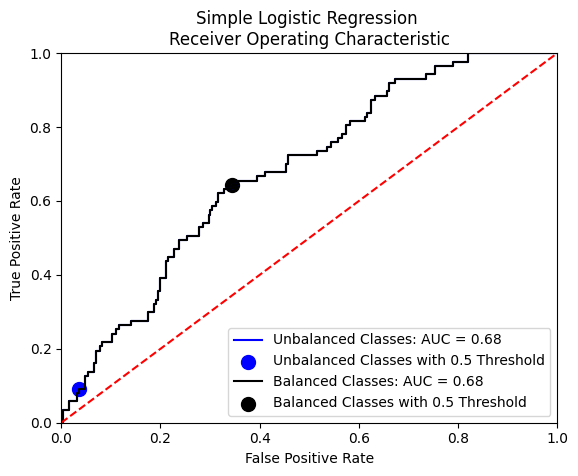

In [26]:
# Unbalanced Simple Logistic Regression Model
probs = simple_logreg_unbalanced.predict_proba(df_test[[variable_of_interest]])
preds = probs[:,1]
fpr_simple_unbalanced, tpr_simple_unbalanced, threshold = metrics.roc_curve(df_test['CLASS'], preds)
roc_auc_simple_unbalanced = metrics.auc(fpr_simple_unbalanced, tpr_simple_unbalanced)

# Balanced Simple Logistic Regression Model
probs_simple = simple_logreg.predict_proba(df_test[[variable_of_interest]])
preds_simple = probs_simple[:,1]
fpr_simple, tpr_simple, threshold = metrics.roc_curve(df_test['CLASS'], preds_simple)
roc_auc_simple = metrics.auc(fpr_simple, tpr_simple)

# Scikit-learn uses a default threshold value of 0.5

# From the confusion matrix, you can plot the operating characteristic for the model
# Unbalanced Logistic Regression Model
fpr_50_simple_unbalanced = 1- specificity_LR_simple_unbalanced
tpr_50_simple_unbalanced = sensitivity_LR_simple_unbalanced
# Balanced Logistic Regression Model
fpr_50_simple = 1- specificity_LR_simple  
tpr_50_simple = sensitivity_LR_simple

# Create ROC curve plot
plt.title('Simple Logistic Regression \nReceiver Operating Characteristic')
plt.plot(fpr_simple_unbalanced, tpr_simple_unbalanced, 'b', label = 'Unbalanced Classes: AUC = %0.2f' % roc_auc_simple_unbalanced)
plt.scatter(fpr_50_simple_unbalanced, tpr_50_simple_unbalanced, s=100, marker='o', c='b', label = 'Unbalanced Classes with 0.5 Threshold')
plt.plot(fpr_simple, tpr_simple, 'black', label = 'Balanced Classes: AUC = %0.2f' % roc_auc_simple)
plt.scatter(fpr_50_simple, tpr_50_simple, s=100, marker='o', c='black', label = 'Balanced Classes with 0.5 Threshold')

plt.legend(loc = 'lower right')
plt.plot([0, 1], [0, 1],'r--')
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.show()

Now comparing the balanced simple logistic regression against the balanced multivariate logistic regression:

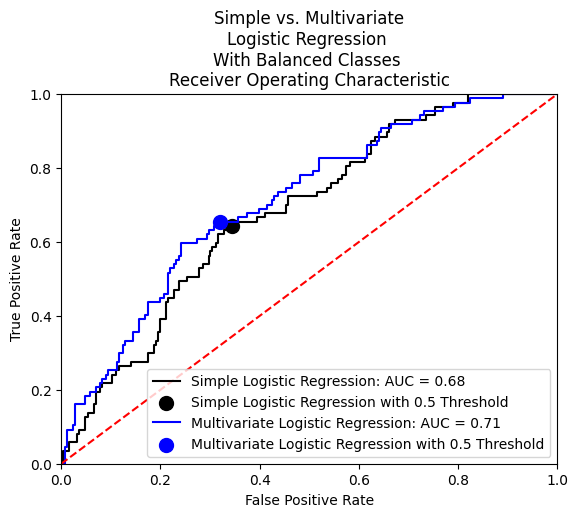

In [27]:
# Balanced Simple Logistic Regression Model
probs_simple = simple_logreg.predict_proba(df_test[[variable_of_interest]])
preds_simple = probs_simple[:,1]
fpr_simple, tpr_simple, threshold = metrics.roc_curve(df_test['CLASS'], preds_simple)
roc_auc_simple = metrics.auc(fpr_simple, tpr_simple)

# Balanced Multivariate Logistic Regression Model
probs_MLR = logreg.predict_proba(X_test_std)
preds_MLR = probs_MLR[:,1]
fpr_MLR, tpr_MLR, threshold = metrics.roc_curve(y_test, preds_MLR)
roc_auc_MLR = metrics.auc(fpr_MLR, tpr_MLR)

# Scikit-learn uses a default threshold value of 0.5

# From the confusion matrix, you can plot the operating characteristic for the model
# Balanced Simple Logistic Regression Model
fpr_50_simple = 1- specificity_LR_simple  
tpr_50_simple = sensitivity_LR_simple
# Balanced Multivariate Logistic Model
fpr_50_MLR = 1- specificity_LR  
tpr_50_MLR = sensitivity_LR

# Create ROC curve plot
plt.title('Simple vs. Multivariate\nLogistic Regression \nWith Balanced Classes \nReceiver Operating Characteristic')
plt.plot(fpr_simple, tpr_simple, 'black', label = 'Simple Logistic Regression: AUC = %0.2f' % roc_auc_simple)
plt.scatter(fpr_50_simple, tpr_50_simple, s=100, marker='o', c='black', label = 'Simple Logistic Regression with 0.5 Threshold')
plt.plot(fpr_MLR, tpr_MLR, 'blue', label = 'Multivariate Logistic Regression: AUC = %0.2f' % roc_auc_MLR)
plt.scatter(fpr_50_MLR, tpr_50_MLR, s=100, marker='o', c='blue', label = 'Multivariate Logistic Regression with 0.5 Threshold')

plt.legend(loc = 'lower right')
plt.plot([0, 1], [0, 1],'r--')
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.show()

**ROC analysis observations:**

- The dotted red line represents a random classifier (AUC = 0.5) — the baseline that any useful model must exceed.
- Balancing the classes noticeably improves the AUC compared to the unbalanced model, confirming the importance of addressing class imbalance.
- The multivariate logistic regression achieves a higher AUC than the simple version, reflecting the benefit of including all three features. More of the curve pushes toward the upper-left corner (high sensitivity, low false positive rate).

## 4. Linear Discriminant Analysis (LDA)

### 4.1 Simple LDA — Single Feature

LDA models each class as a Gaussian distribution and finds the linear boundary that best separates them. Unlike logistic regression, LDA explicitly estimates class-conditional distributions and uses Bayes' theorem.

Training a simple LDA using only LST on the SMOTE-balanced training data:

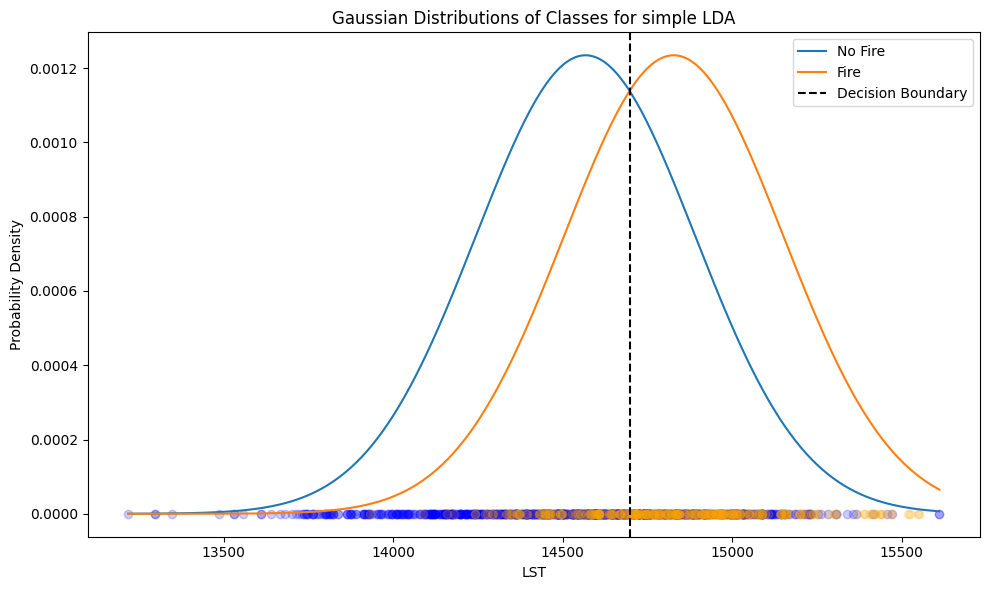

No Fire Class Mean LST: 14567.493
Fire Class Mean LST:    14827.585
Standard Deviation:     323.146

LDA Decision Boundary is at: 14697.539


In [28]:
# Train a simple LDA model using the training data set
lda_simple = LinearDiscriminantAnalysis(store_covariance =  True)
lda_simple.fit(os_X_train_simple, os_y_train) 
# Note that os_X_train_simple and os_y_train were created
# in the code block following Exercise 8 using SMOTE.

# Generate a range of values for plotting the Gaussian distributions
X_range = np.linspace(df_train[variable_of_interest].min(), df_train[variable_of_interest].max(), 300)

# Extract means and shared variance (covariance of only one feature)
means = lda_simple.means_.flatten()
covariance = lda_simple.covariance_[0, 0]  # Since it's 1D, we take the scalar value
std_dev = np.sqrt(covariance)

# Plot Gaussian distributions for each class
plt.figure(figsize=(10, 6))
for i, label in enumerate(['No Fire', 'Fire']):
    plt.plot(X_range, norm.pdf(X_range, means[i], std_dev), label=label)

# Plot the training data
plt.scatter(df_train[df_train.CLASS == 0][variable_of_interest], np.zeros(len(df_train[df_train.CLASS == 0])), color='blue', alpha=0.2)
plt.scatter(df_train[df_train.CLASS == 1][variable_of_interest], np.zeros(len(df_train[df_train.CLASS == 1])), color='orange', alpha=0.2)

# Add vertical decision boundary
decision_boundary = (means[0] + means[1]) / 2
plt.axvline(x=decision_boundary, color='black', linestyle='--', label='Decision Boundary')

plt.title('Gaussian Distributions of Classes for simple LDA')
plt.xlabel(variable_of_interest)
plt.ylabel('Probability Density')
plt.legend()
plt.tight_layout()
plt.show()

# Print out the mean and standard deviation for the Gaussian distributions for each class
print('No Fire Class Mean LST: %.3f' %means[0])
print('Fire Class Mean LST:    %.3f' %means[1])
print('Standard Deviation:     %.3f' %std_dev)

# Print decision boundary
print(f"\nLDA Decision Boundary is at: {decision_boundary:.3f}")

**LDA Gaussian distributions:**

LDA assumes a *shared* covariance across all classes. With a single feature (LST), this means both the "No Fire" and "Fire" Gaussians have the same standard deviation (~323) but different means (14,567 vs. 14,828). The decision boundary falls at the point where the two Gaussian densities intersect (~14,698).

Because the distributions overlap substantially, a single feature cannot cleanly separate the classes.

Evaluating the simple LDA on the test set:

In [29]:
# Use the LDA model to predict whether or not there is a fire in each test observation
y_pred = lda_simple.predict(df_test[[variable_of_interest]])

# Create a confusion matrix
cnf_matrix = metrics.confusion_matrix(df_test['CLASS'], y_pred)
print('The confusion matrix is:')
print(cnf_matrix)

# Report on performance metrics
[accuracy_lda_simple, specificity_lda_simple, sensitivity_lda_simple, precision_lda_simple] = classification_metrics(cnf_matrix)
print('Accuracy:    %.3f' %accuracy_lda_simple)
print('Specificity: %.3f' %specificity_lda_simple)
print('Sensitivity: %.3f' %sensitivity_lda_simple)
print('Precision:   %.3f' %precision_lda_simple)

The confusion matrix is:
[[168  88]
 [ 31  56]]
Accuracy:    0.653
Specificity: 0.656
Sensitivity: 0.644
Precision:   0.389


### 4.2 LDA — Two Features

Let's examine how LDA performs with each pair of features. The decision boundary in 2D is a straight line (linear), and the class-conditional distributions are bivariate Gaussians with shared covariance.

In [30]:
def analyze_da_features(da_model, os_X_train_std, X_test_std, y_test, x_axis_feature, y_axis_feature, class_labels=['No Fire', 'Fire']):

    # Select only the two features used for analysis
    selected_features = [x_axis_feature, y_axis_feature]
    os_X_train_selected = os_X_train_std[selected_features]
    X_test_selected = X_test_std[selected_features]

    # Extract means and covariance
    means = da_model.means_
    covariance = da_model.covariance_
    is_qda = isinstance(covariance, list)

    # Set column widths
    wide_col_width = max(len(name) for name in selected_features)
    standard_width = 10

    # Print class means
    print(f"Class Means ({x_axis_feature} and {y_axis_feature}):")
    for i, label in enumerate(class_labels):
        print(f"{label}:")
        for j, feature in enumerate(selected_features):
            print(f"  {feature:<{wide_col_width}}: {means[i][j]:.3f}")

    # Print covariance matrix/matrices
    if is_qda:
        for c, label in enumerate(class_labels):
            print(f"\nCovariance matrix for class '{label}':")
            header = f"{'':<{wide_col_width + 2}}" + "  ".join(f"{feature:<{standard_width}}" for feature in selected_features)
            print(header)
            for i in range(2):
                row_str = f"{selected_features[i]:<{wide_col_width}}  " + "  ".join(
                    f"{float(covariance[c][i][j]):<{standard_width}.3f}" for j in range(2))
                print(row_str)
    else:
        print("\nShared covariance matrix (LDA):")
        header = f"{'':<{wide_col_width + 2}}" + "  ".join(f"{feature:<{standard_width}}" for feature in selected_features)
        print(header)
        for i in range(2):
            row_str = f"{selected_features[i]:<{wide_col_width}}  " + "  ".join(
                f"{float(covariance[i][j]):<{standard_width}.3f}" for j in range(2))
            print(row_str)

    # Predict and evaluate
    y_pred = da_model.predict(X_test_selected)
    cnf_matrix = metrics.confusion_matrix(y_test, y_pred)

    # Report test metrics
    [accuracy, specificity, sensitivity, precision] = classification_metrics(cnf_matrix)
    print('\nAccuracy:    %.3f' % accuracy)
    print('Specificity: %.3f' % specificity)
    print('Sensitivity: %.3f' % sensitivity)
    print('Precision:   %.3f' % precision)

In [31]:
def plot_da_contours_custom_features(da_model, os_X_train_std, x_axis_feature, y_axis_feature, class_labels=['No Fire', 'Fire']):
    import numpy as np
    import matplotlib.pyplot as plt
    from scipy.stats import multivariate_normal
    from matplotlib.colors import ListedColormap
    import pandas as pd

    # Use only the two selected features
    selected_features = [x_axis_feature, y_axis_feature]
    X_selected = os_X_train_std[selected_features]

    x = np.linspace(X_selected[x_axis_feature].min(), X_selected[x_axis_feature].max(), 300)
    y = np.linspace(X_selected[y_axis_feature].min(), X_selected[y_axis_feature].max(), 300)
    X, Y = np.meshgrid(x, y)
    pos = np.dstack((X, Y))

    plt.figure(figsize=(10, 6))

    means = da_model.means_
    covariance = da_model.covariance_
    is_qda = isinstance(covariance, list)

    for i, label in enumerate(class_labels):
        mean_2d = [means[i][0], means[i][1]]  # Only two features
        if is_qda:
            cov_2d = covariance[i][np.ix_([0, 1], [0, 1])]
        else:
            cov_2d = covariance[np.ix_([0, 1], [0, 1])]
        rv = multivariate_normal(mean_2d, cov_2d)
        plt.contour(X, Y, rv.pdf(pos), levels=5, linestyles='dashed')

    # Create grid for decision boundary
    grid_points = np.c_[X.ravel(), Y.ravel()]
    dummy_df = pd.DataFrame(grid_points, columns=selected_features)
    Z = da_model.predict(dummy_df).reshape(X.shape)

    cmap_background = ListedColormap(['#AAAAFF', '#FFA500'])  # Blue for No Fire, Orange for Fire
    plt.contourf(X, Y, Z, alpha=0.3, cmap=cmap_background)

    # Annotate regions
    fire_mask = Z == 1
    no_fire_mask = Z == 0
    fire_x = X[fire_mask]
    fire_y = Y[fire_mask]
    no_fire_x = X[no_fire_mask]
    no_fire_y = Y[no_fire_mask]

    if len(fire_x) > 0 and len(fire_y) > 0:
        plt.text(np.mean(fire_x), np.mean(fire_y), 'Fire Region', fontsize=12, color='black', ha='center')
    if len(no_fire_x) > 0 and len(no_fire_y) > 0:
        plt.text(np.mean(no_fire_x), np.mean(no_fire_y), 'No Fire Region', fontsize=12, color='black', ha='center')

    plt.title('Gaussian Distributions and Decision Boundary from DA Model')
    plt.xlabel(x_axis_feature)
    plt.ylabel(y_axis_feature)
    plt.tight_layout()
    plt.show()

#### NDVI and LST

Class Means (NDVI and LST):
No Fire:
  NDVI: 0.087
  LST : -0.151
Fire:
  NDVI: -0.253
  LST : 0.557

Shared covariance matrix (LDA):
      NDVI        LST       
NDVI  0.846       0.025     
LST   0.025       0.760     

Accuracy:    0.671
Specificity: 0.672
Sensitivity: 0.667
Precision:   0.408


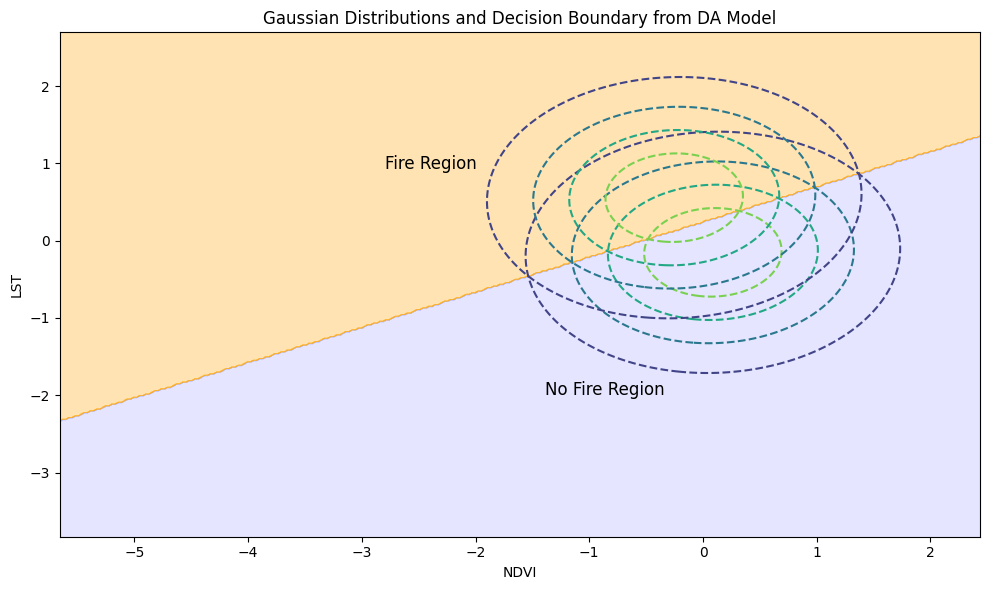

In [32]:
x_axis_feature = 'NDVI'
y_axis_feature = 'LST'

lda2 = LinearDiscriminantAnalysis(store_covariance=True)
lda2.fit(os_X_train_std[[x_axis_feature, y_axis_feature]], os_y_train)

analyze_da_features(lda2, os_X_train_std, X_test_std, y_test, x_axis_feature, y_axis_feature, class_labels=['No Fire', 'Fire'])
plot_da_contours_custom_features(lda2, os_X_train_std, x_axis_feature, y_axis_feature, class_labels=['No Fire', 'Fire'])

#### THERMAL_ANOMALIES and LST

Class Means (THERMAL_ANOMALIES and LST):
No Fire:
  THERMAL_ANOMALIES: -0.038
  LST              : -0.151
Fire:
  THERMAL_ANOMALIES: 0.167
  LST              : 0.557

Shared covariance matrix (LDA):
                   THERMAL_ANOMALIES  LST       
THERMAL_ANOMALIES  0.975       0.127     
LST                0.127       0.760     

Accuracy:    0.638
Specificity: 0.641
Sensitivity: 0.632
Precision:   0.374


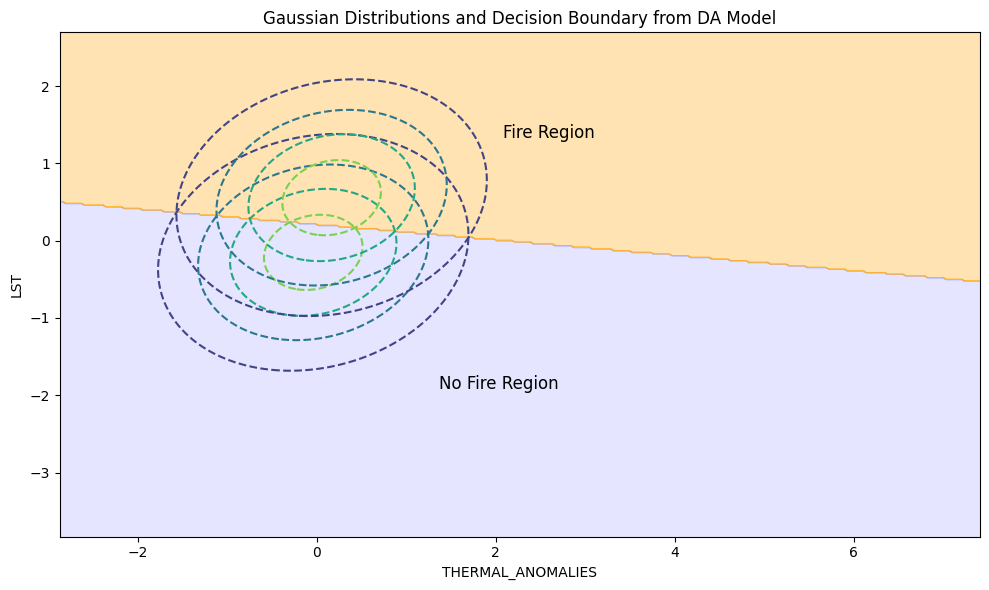

In [33]:
x_axis_feature = 'THERMAL_ANOMALIES'
y_axis_feature = 'LST'

lda2 = LinearDiscriminantAnalysis(store_covariance=True)
lda2.fit(os_X_train_std[[x_axis_feature, y_axis_feature]], os_y_train)

analyze_da_features(lda2, os_X_train_std, X_test_std, y_test, x_axis_feature, y_axis_feature, class_labels=['No Fire', 'Fire'])
plot_da_contours_custom_features(lda2, os_X_train_std, x_axis_feature, y_axis_feature, class_labels=['No Fire', 'Fire'])

#### THERMAL_ANOMALIES and NDVI

Class Means (THERMAL_ANOMALIES and NDVI):
No Fire:
  THERMAL_ANOMALIES: -0.038
  NDVI             : 0.087
Fire:
  THERMAL_ANOMALIES: 0.167
  NDVI             : -0.253

Shared covariance matrix (LDA):
                   THERMAL_ANOMALIES  NDVI      
THERMAL_ANOMALIES  0.975       -0.045    
NDVI               -0.045      0.846     

Accuracy:    0.592
Specificity: 0.578
Sensitivity: 0.632
Precision:   0.337


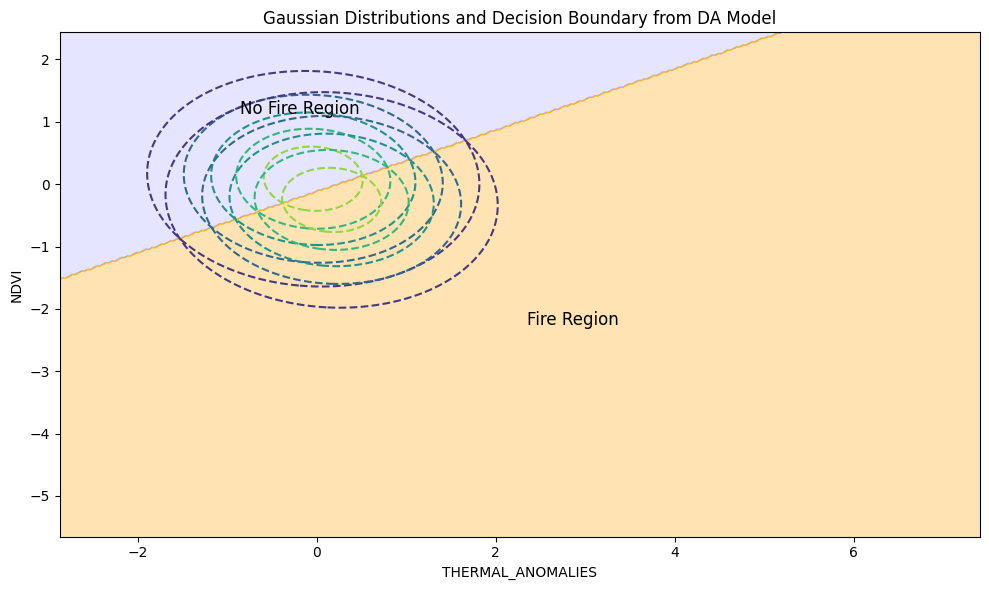

In [34]:
x_axis_feature = 'THERMAL_ANOMALIES'
y_axis_feature = 'NDVI'

lda2 = LinearDiscriminantAnalysis(store_covariance=True)
lda2.fit(os_X_train_std[[x_axis_feature, y_axis_feature]], os_y_train)

analyze_da_features(lda2, os_X_train_std, X_test_std, y_test, x_axis_feature, y_axis_feature, class_labels=['No Fire', 'Fire'])
plot_da_contours_custom_features(lda2, os_X_train_std, x_axis_feature, y_axis_feature, class_labels=['No Fire', 'Fire'])

**Two-feature LDA observations:**

- The contours are **elliptical** because LDA models each class as a bivariate Gaussian — the level curves of a 2D Gaussian are always ellipses.
- Since LDA enforces a **shared covariance matrix**, both classes produce identically-shaped ellipses (same orientation and aspect ratio), just centered at different means.
- The decision boundary is a **straight line** in all cases — this is the defining property of LDA.
- All three feature pairs yield similar performance, with only modest improvements over the single-feature case. This suggests the features contain overlapping information about fire presence.

### 4.3 LDA — Three Features

Using all three features together for the fullest picture:

In [35]:
# Train a LDA model using the balanced and standardized
# training data set with all three features
lda = LinearDiscriminantAnalysis(store_covariance =  True)
lda.fit(os_X_train_std, os_y_train)

# Using the LDA model, predict whether or not their is a fire in each test observation
y_pred = lda.predict(X_test_std)

# Create the confusion matrix
cnf_matrix = metrics.confusion_matrix(y_test, y_pred)
print('The confusion matrix is:')
print(cnf_matrix)

# Report test metrics
[accuracy_lda, specificity_lda, sensitivity_lda, precision_lda] = classification_metrics(cnf_matrix)
print('Accuracy:    %.3f' %accuracy_lda)
print('Specificity: %.3f' %specificity_lda)
print('Sensitivity: %.3f' %sensitivity_lda)
print('Precision:   %.3f' %precision_lda)

The confusion matrix is:
[[173  83]
 [ 31  56]]
Accuracy:    0.668
Specificity: 0.676
Sensitivity: 0.644
Precision:   0.403


Examining the learned class means and shared covariance matrix:

In [36]:
# Extract feature names
feature_names = os_X_train_std.columns.tolist()

# Extract means and shared covariance matrix
means = lda.means_  # shape: (n_classes, 3)
covariance = lda.covariance_  # shape: (3, 3)

# Set column widths
wide_col_width = max(len(name) for name in feature_names)  # for left-most column
standard_width = 10  # for numerical columns

# Print class means with aligned columns
print("Class Means (3 features):")
for i, label in enumerate(['No Fire', 'Fire']):
    print(f"{label}:")
    for j, feature in enumerate(feature_names):
        print(f"  {feature:<{wide_col_width}}: {means[i][j]:.3f}")

# Print shared covariance matrix with wide left column and standard width for others
print("\nShared Covariance Matrix:")
header = f"{'':<{wide_col_width +2}}" + "  ".join(f"{name:<{standard_width}}" for name in feature_names)
print(header)
for i, row in enumerate(covariance):
    row_str = f"{feature_names[i]:<{wide_col_width}}  " + "  ".join(f"{val:<{standard_width}.3f}" for val in row)
    print(row_str)    

Class Means (3 features):
No Fire:
  NDVI             : 0.087
  LST              : -0.151
  THERMAL_ANOMALIES: -0.038
Fire:
  NDVI             : -0.253
  LST              : 0.557
  THERMAL_ANOMALIES: 0.167

Shared Covariance Matrix:
                   NDVI        LST         THERMAL_ANOMALIES
NDVI               0.846       0.025       -0.045    
LST                0.025       0.760       0.127     
THERMAL_ANOMALIES  -0.045      0.127       0.975     


### Visualizing 3D Classification in 2D

With three features, we can't directly plot the full decision boundary. Instead, we project the test results onto pairs of features to see how well the classifier separates the classes in each 2D slice:

In [37]:
def LDA_2D_plot_custom(lda_model, x_axis_feature, y_axis_feature,
                       X_test_std, y_test, y_pred, class_labels=['No Fire', 'Fire']):
    """
    Plots a 2D scatter plot of LDA classification results using two selected features.
    
    Parameters:
    - lda_model: trained LinearDiscriminantAnalysis model
    - x_axis_feature: name of feature for x-axis
    - y_axis_feature: name of feature for y-axis
    - X_test_std: standardized test DataFrame
    - y_test: true labels for test set
    - y_pred: predicted labels from LDA model
    - class_labels: list of class names (default ['No Fire', 'Fire'])
    """
    
    # Identify true positives and false positives
    tp = (y_test == y_pred)
    tp0, tp1 = tp[y_test == 0], tp[y_test == 1]
    X0, X1 = X_test_std[y_test == 0], X_test_std[y_test == 1]
    X0_tp, X0_fp = X0[tp0], X0[~tp0]
    X1_tp, X1_fp = X1[tp1], X1[~tp1]

    # Plot class 0: dots and crosses
    plt.scatter(X0_tp[x_axis_feature], X0_tp[y_axis_feature], marker='.', color='blue', label=f'{class_labels[0]} TP')
    plt.scatter(X0_fp[x_axis_feature], X0_fp[y_axis_feature], marker='x', s=20, color='#000099', label=f'{class_labels[0]} FP')

    # Plot class 1: dots and crosses
    plt.scatter(X1_tp[x_axis_feature], X1_tp[y_axis_feature], marker='.', color='red', label=f'{class_labels[1]} TP')
    plt.scatter(X1_fp[x_axis_feature], X1_fp[y_axis_feature], marker='x', s=20, color='#990000', label=f'{class_labels[1]} FP')

    # Plot class means
    feature_names = X_test_std.columns.tolist()
    x_idx = feature_names.index(x_axis_feature)
    y_idx = feature_names.index(y_axis_feature)
    plt.plot(lda_model.means_[0][x_idx], lda_model.means_[0][y_idx], '*', color='yellow', markersize=15, markeredgecolor='blue')
    plt.plot(lda_model.means_[1][x_idx], lda_model.means_[1][y_idx], '*', color='yellow', markersize=15, markeredgecolor='red')

    # Axis labels and legend
    plt.xlabel(x_axis_feature)
    plt.ylabel(y_axis_feature)
    plt.title('3 Feature LDA as a 2D Classification Plot')
    plt.legend()
    plt.tight_layout()
    plt.show()

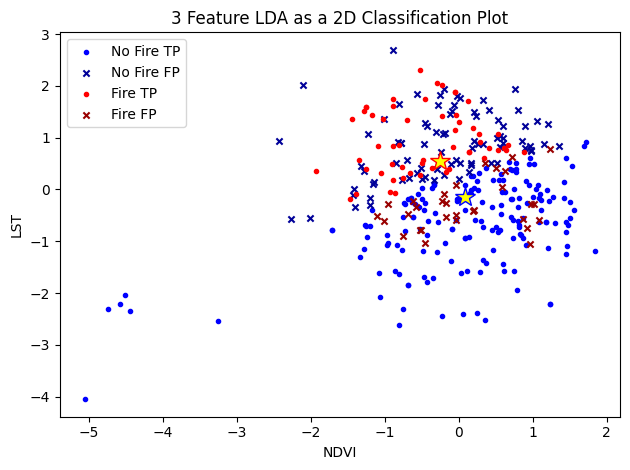

In [38]:
x_axis_feature = 'NDVI'
y_axis_feature = 'LST'

LDA_2D_plot_custom(lda, x_axis_feature, y_axis_feature,
                       X_test_std, y_test, y_pred, class_labels=['No Fire', 'Fire'])

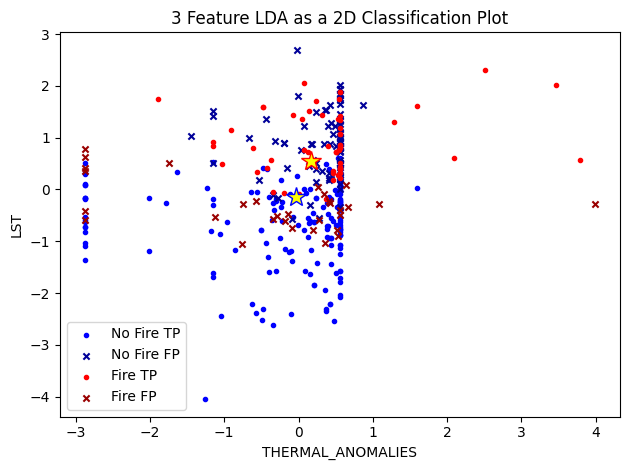

In [39]:
x_axis_feature = 'THERMAL_ANOMALIES'
y_axis_feature = 'LST'

LDA_2D_plot_custom(lda, x_axis_feature, y_axis_feature,
                       X_test_std, y_test, y_pred, class_labels=['No Fire', 'Fire'])

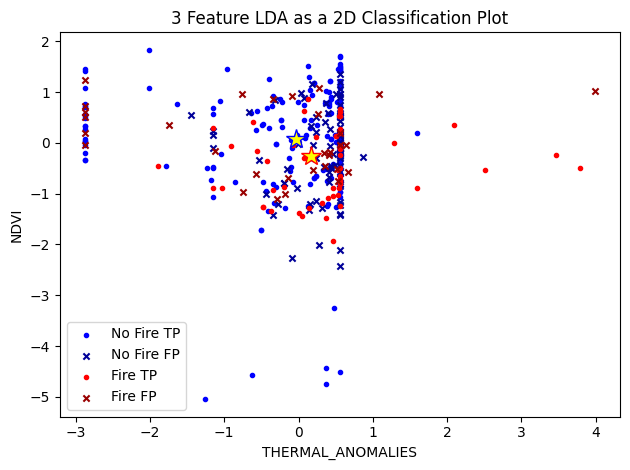

In [40]:
x_axis_feature = 'THERMAL_ANOMALIES'
y_axis_feature = 'NDVI'

LDA_2D_plot_custom(lda, x_axis_feature, y_axis_feature,
                       X_test_std, y_test, y_pred, class_labels=['No Fire', 'Fire'])

**Note on 2D projections of 3D classifiers:**

When projecting a three-dimensional classification into two dimensions, spatial relationships can appear misleading. For example, the Fire class mean may appear surrounded by No Fire points in one 2D view, even though the classes are well-separated along the third (hidden) axis. This is an artifact of dimensional reduction, not a flaw in the classifier.

To get a more faithful 2D view, we can use **Principal Component Analysis (PCA)** to project the 3D feature space onto its two directions of greatest variance:

/cluster/home/jmonta04/.local/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(


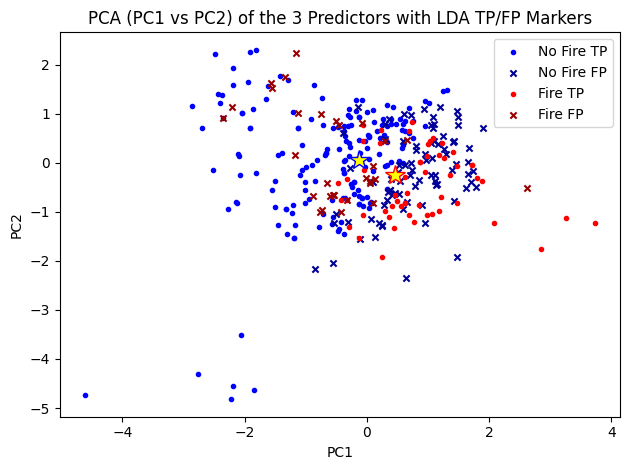

In [41]:
from sklearn.decomposition import PCA

# The same standardized test set nd predictions
pca = PCA(n_components=2, random_state=0)

pca.fit(X_train_std)

# Transforming test points into PC space
PC_test = pca.transform(X_test_std)
PC_test = pd.DataFrame(PC_test, columns=["PC1", "PC2"], index=X_test_std.index)

tp = (y_test == y_pred)
tp0, tp1 = tp[y_test == 0], tp[y_test == 1]

PC0, PC1 = PC_test[y_test == 0], PC_test[y_test == 1]
PC0_tp, PC0_fp = PC0[tp0], PC0[~tp0]
PC1_tp, PC1_fp = PC1[tp1], PC1[~tp1]

# Plot: class No Fire
plt.scatter(PC0_tp["PC1"], PC0_tp["PC2"], marker=".", color="blue", label="No Fire TP")
plt.scatter(PC0_fp["PC1"], PC0_fp["PC2"], marker="x", s=20, color="#000099", label="No Fire FP")

# Plot: class Fire
plt.scatter(PC1_tp["PC1"], PC1_tp["PC2"], marker=".", color="red", label="Fire TP")
plt.scatter(PC1_fp["PC1"], PC1_fp["PC2"], marker="x", s=20, color="#990000", label="Fire FP")

# Plot class means, but in PC space
means_pc = pca.transform(lda.means_)   
plt.plot(means_pc[0,0], means_pc[0,1], "*", color="yellow", markersize=15, markeredgecolor="blue")
plt.plot(means_pc[1,0], means_pc[1,1], "*", color="yellow", markersize=15, markeredgecolor="red")

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA (PC1 vs PC2) of the 3 Predictors with LDA TP/FP Markers")
plt.legend()
plt.tight_layout()
plt.show()


## 5. Quadratic Discriminant Analysis (QDA)

Unlike LDA, QDA allows each class to have its **own covariance matrix**. This produces curved (quadratic) decision boundaries that can better capture situations where the two classes have different spread or shape in feature space.

### Comparing Class Covariance Structures

Before fitting QDA, let's examine whether the fire and no-fire classes actually have different covariance structures (which would justify QDA over LDA):

In [42]:
# All Training Data Covariance Matrix
all_training_data = df_train.drop('CLASS', axis =1)
print('All Training Data Covariance Matrix:')
print(all_training_data.cov().round(3))
print('\n')

# Fire Training Data Covariance Matrix
fire_training_data = df_train[df_train["CLASS"] == 1]
fire_training_data = fire_training_data.drop(['CLASS'], axis = 1)
print('Fire Training Data Covariance Matrix:')
print(fire_training_data.cov().round(3))
print('\n')

# No Fire Training Data Covariance Matrix
no_fire_training_data = df_train[df_train["CLASS"] == 0]
no_fire_training_data = no_fire_training_data.drop(['CLASS'], axis = 1)
print('No Fire Training Data Covariance Matrix:')
print(no_fire_training_data.cov().round(3))
print('\n')


All Training Data Covariance Matrix:
                    NDVI         LST  THERMAL_ANOMALIES
NDVI               0.009       2.291             -0.002
LST                2.291  132303.024             34.968
THERMAL_ANOMALIES -0.002      34.968              0.334


Fire Training Data Covariance Matrix:
                    NDVI        LST  THERMAL_ANOMALIES
NDVI               0.006     -3.494             -0.004
LST               -3.494  85074.508             32.935
THERMAL_ANOMALIES -0.004     32.935              0.422


No Fire Training Data Covariance Matrix:
                    NDVI         LST  THERMAL_ANOMALIES
NDVI               0.009       5.526             -0.001
LST                5.526  131342.257             28.937
THERMAL_ANOMALIES -0.001      28.937              0.306




The Fire and No Fire classes clearly have different covariance structures — the diagonal values (variances) and off-diagonal values (correlations) differ between classes. This suggests QDA, which models each class with its own covariance, should capture the data structure better than LDA's shared-covariance assumption.

### 5.1 Simple QDA — Single Feature

Training a QDA using only LST. Unlike simple LDA, the two Gaussians now have *different* standard deviations — QDA allows the spread of each class to vary independently:

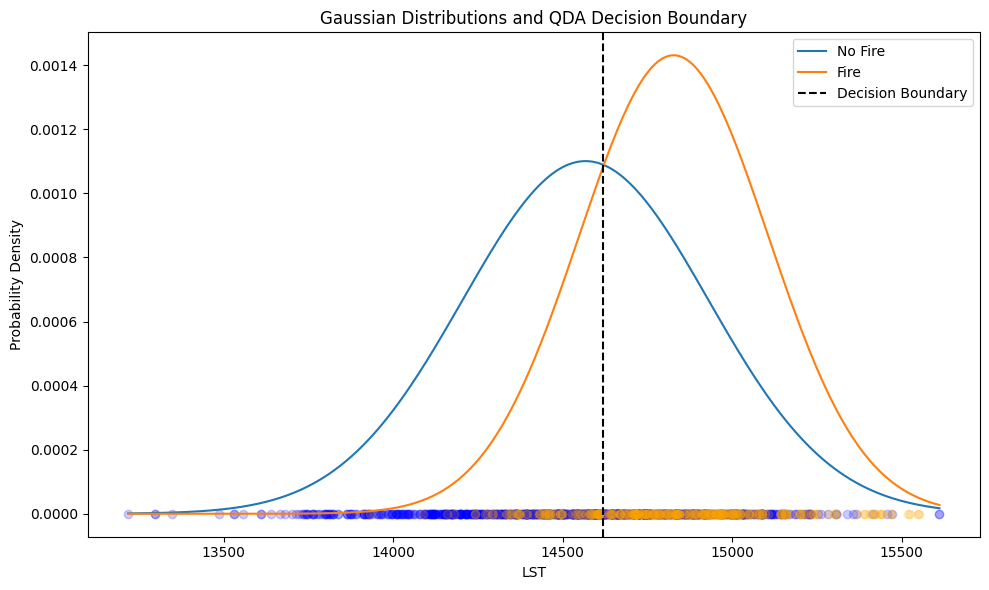

No Fire Class Mean LST: 14567.493
Fire Class Mean LST:    14827.585
No Fire Class Standard Deviation: 362.412
Fire Class Standard Deviation:    278.747

QDA Decision Boundary is at: 14618.919


In [43]:
# Define variable of interest
variable_of_interest = 'LST'

# Train simple QDA model on balanced, standardized data 
qda_simple = QuadraticDiscriminantAnalysis(store_covariance=True)
qda_simple.fit(os_X_train_simple, os_y_train)

# Generate range of values for plotting and decision boundary
X_range = np.linspace(df_train[variable_of_interest].min(), df_train[variable_of_interest].max(), 300)
X_range_reshaped = pd.DataFrame(X_range, columns=[variable_of_interest])

# Predict posterior probabilities
posterior_probs = qda_simple.predict_proba(X_range_reshaped)

# Find decision boundary: point where posterior probabilities are equal
prob_diff = np.abs(posterior_probs[:, 0] - posterior_probs[:, 1])
decision_index = np.argmin(prob_diff)
decision_boundary = X_range[decision_index]

# Extract means and variances for each class
means = qda_simple.means_.flatten()
covariances = [qda_simple.covariance_[i][0, 0] for i in range(len(qda_simple.classes_))]
std_devs = [np.sqrt(cov) for cov in covariances]

# Plot Gaussian distributions
plt.figure(figsize=(10, 6))
for i, label in enumerate(['No Fire', 'Fire']):
    plt.plot(X_range, norm.pdf(X_range, means[i], std_devs[i]), label=label)

# Scatter plot of training data
plt.scatter(df_train[df_train.CLASS == 0][variable_of_interest], np.zeros(len(df_train[df_train.CLASS == 0])), color='blue', alpha=0.2)
plt.scatter(df_train[df_train.CLASS == 1][variable_of_interest], np.zeros(len(df_train[df_train.CLASS == 1])), color='orange', alpha=0.2)

# Plot decision boundary
plt.axvline(x=decision_boundary, color='black', linestyle='--', label='Decision Boundary')

# Labels and legend
plt.title('Gaussian Distributions and QDA Decision Boundary')
plt.xlabel(variable_of_interest)
plt.ylabel('Probability Density')
plt.legend()
plt.tight_layout()
plt.show()

# Print out the mean and standard deviation for the Gaussian distributions for each class
print('No Fire Class Mean LST: %.3f' %means[0])
print('Fire Class Mean LST:    %.3f' %means[1])
print('No Fire Class Standard Deviation: %.3f' %std_devs[0])
print('Fire Class Standard Deviation:    %.3f' %std_devs[1])

# Print decision boundary
print(f"\nQDA Decision Boundary is at: {decision_boundary:.3f}")

**Simple QDA vs. Simple LDA:**

Both models estimate the same class means for LST, but QDA estimates different standard deviations for each class (No Fire: 362, Fire: 279). This shifts the decision boundary compared to LDA. The QDA boundary moves closer to the No Fire mean, reflecting the tighter spread of the Fire class — QDA is more confident that extreme LST values belong to fires.

### 5.2 QDA — Two Features

With two features, QDA produces **curved** decision boundaries (elliptical or hyperbolic) rather than LDA's straight lines:

#### NDVI and LST

Class Means (NDVI and LST):
No Fire:
  NDVI: 0.087
  LST : -0.151
Fire:
  NDVI: -0.253
  LST : 0.557

Covariance matrix for class 'No Fire':
      NDVI        LST       
NDVI  1.058       0.162     
LST   0.162       0.976     

Covariance matrix for class 'Fire':
      NDVI        LST       
NDVI  0.635       -0.112    
LST   -0.112      0.546     

Accuracy:    0.641
Specificity: 0.613
Sensitivity: 0.724
Precision:   0.389


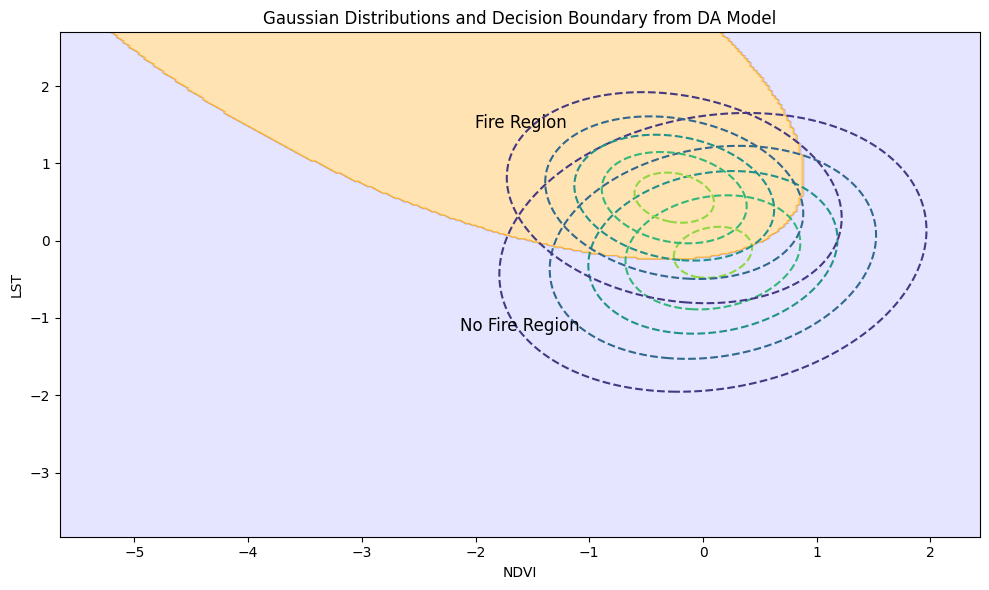

In [44]:
x_axis_feature = 'NDVI'
y_axis_feature = 'LST'

qda2 = QuadraticDiscriminantAnalysis(store_covariance=True)
qda2.fit(os_X_train_std[[x_axis_feature, y_axis_feature]], os_y_train)

analyze_da_features(qda2, os_X_train_std, X_test_std, y_test, x_axis_feature, y_axis_feature, class_labels=['No Fire', 'Fire'])
plot_da_contours_custom_features(qda2, os_X_train_std, x_axis_feature, y_axis_feature, class_labels=['No Fire', 'Fire'])    

#### THERMAL_ANOMALIES and LST

Class Means (THERMAL_ANOMALIES and LST):
No Fire:
  THERMAL_ANOMALIES: -0.038
  LST              : -0.151
Fire:
  THERMAL_ANOMALIES: 0.167
  LST              : 0.557

Covariance matrix for class 'No Fire':
                   THERMAL_ANOMALIES  LST       
THERMAL_ANOMALIES  0.898       0.135     
LST                0.135       0.976     

Covariance matrix for class 'Fire':
                   THERMAL_ANOMALIES  LST       
THERMAL_ANOMALIES  1.053       0.119     
LST                0.119       0.546     

Accuracy:    0.592
Specificity: 0.559
Sensitivity: 0.690
Precision:   0.347


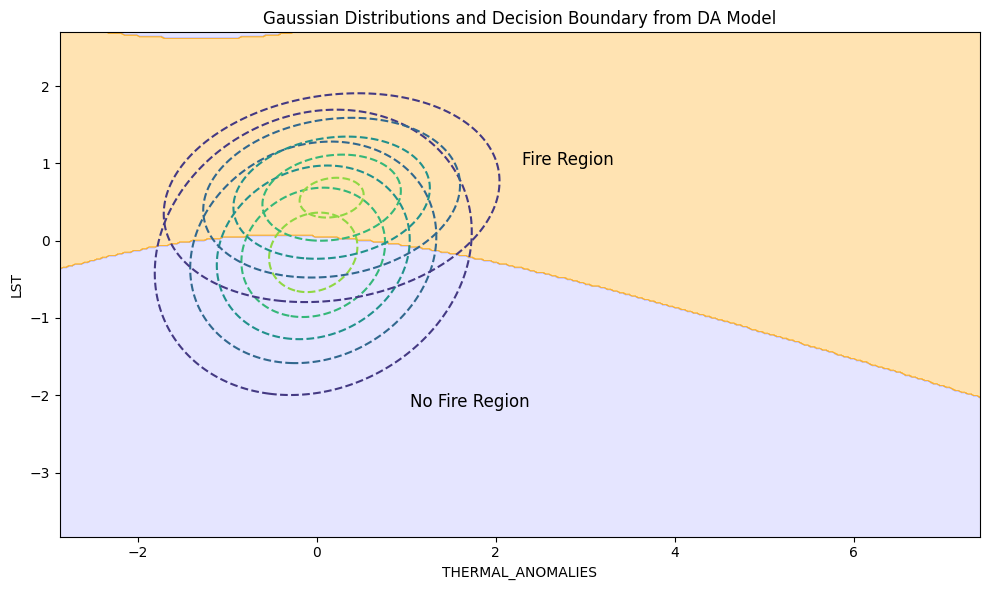

In [45]:
x_axis_feature = 'THERMAL_ANOMALIES'
y_axis_feature = 'LST'

qda2 = QuadraticDiscriminantAnalysis(store_covariance=True)
qda2.fit(os_X_train_std[[x_axis_feature, y_axis_feature]], os_y_train)

analyze_da_features(qda2, os_X_train_std, X_test_std, y_test, x_axis_feature, y_axis_feature, class_labels=['No Fire', 'Fire'])
plot_da_contours_custom_features(qda2, os_X_train_std, x_axis_feature, y_axis_feature, class_labels=['No Fire', 'Fire'])    

#### THERMAL_ANOMALIES and NDVI

Class Means (THERMAL_ANOMALIES and NDVI):
No Fire:
  THERMAL_ANOMALIES: -0.038
  NDVI             : 0.087
Fire:
  THERMAL_ANOMALIES: 0.167
  NDVI             : -0.253

Covariance matrix for class 'No Fire':
                   THERMAL_ANOMALIES  NDVI      
THERMAL_ANOMALIES  0.898       -0.012    
NDVI               -0.012      1.058     

Covariance matrix for class 'Fire':
                   THERMAL_ANOMALIES  NDVI      
THERMAL_ANOMALIES  1.053       -0.079    
NDVI               -0.079      0.635     

Accuracy:    0.548
Specificity: 0.461
Sensitivity: 0.805
Precision:   0.337


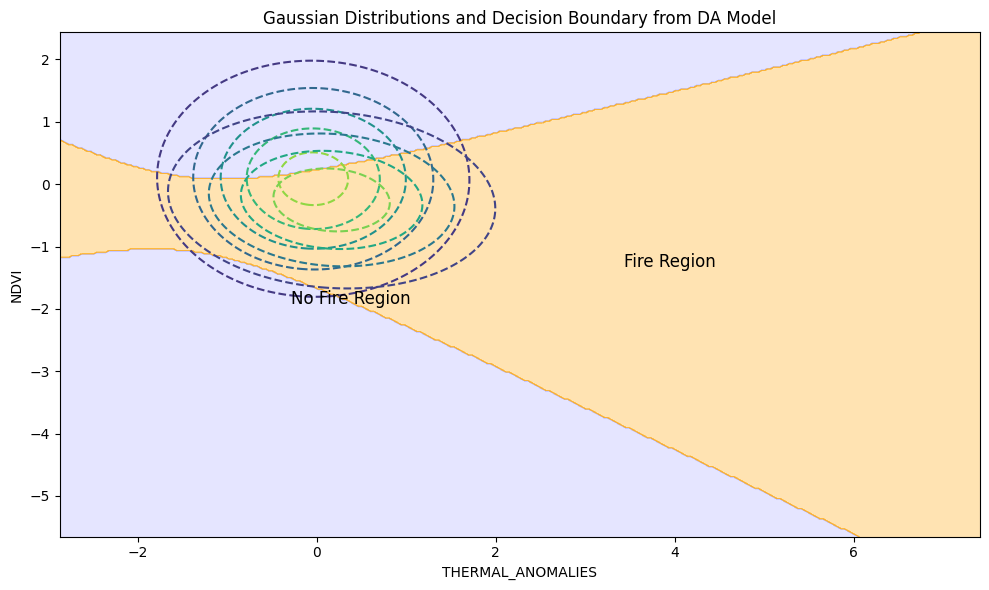

In [46]:
x_axis_feature = 'THERMAL_ANOMALIES'
y_axis_feature = 'NDVI'

qda2 = QuadraticDiscriminantAnalysis(store_covariance=True)
qda2.fit(os_X_train_std[[x_axis_feature, y_axis_feature]], os_y_train)

analyze_da_features(qda2, os_X_train_std, X_test_std, y_test, x_axis_feature, y_axis_feature, class_labels=['No Fire', 'Fire'])
plot_da_contours_custom_features(qda2, os_X_train_std, x_axis_feature, y_axis_feature, class_labels=['No Fire', 'Fire'])    

**Two-feature QDA vs. LDA:**

QDA achieves higher sensitivity than LDA (catches more fires) but at the cost of lower specificity and accuracy (more false alarms). The curved decision boundaries allow QDA to capture the different covariance structures of the two classes, wrapping more tightly around the fire cluster. This flexibility is valuable when, as here, the classes genuinely differ in shape.

### 5.3 QDA — Three Features

Training QDA with all three standardized features on the SMOTE-balanced training set:

In [47]:
# Train QDA on training data
qda_3 = QuadraticDiscriminantAnalysis(store_covariance=True)
qda_3.fit(os_X_train_std, os_y_train)   # SMOTE-balanced, standardized training set

# Predict on standardized test data
y_pred_qda3 = qda_3.predict(X_test_std)

# Get the confusion matrix
cm = metrics.confusion_matrix(y_test, y_pred_qda3)
print("Confusion Matrix:\n", cm, "\n")

# Get the metrics
acc, spec, sens, prec = classification_metrics(cm)
print(f"Accuracy:    {acc:.3f}")
print(f"Specificity: {spec:.3f}")
print(f"Sensitivity: {sens:.3f}")
print(f"Precision:   {prec:.3f}\n")

# Print the results
print("Class order (qda_3.classes_):", qda_3.classes_, "\n")

print("Class means (rows correspond to classes above):")
print(qda_3.means_, "\n")

print("Class covariance matrices:")
for i, cls in enumerate(qda_3.classes_):
    print(f"Covariance matrix for class {cls}:")
    print(qda_3.covariance_[i])
    print()


Confusion Matrix:
 [[158  98]
 [ 25  62]] 

Accuracy:    0.641
Specificity: 0.617
Sensitivity: 0.713
Precision:   0.388

Class order (qda_3.classes_): [0 1] 

Class means (rows correspond to classes above):
[[ 0.08700907 -0.15077918 -0.03810278]
 [-0.25284502  0.55655085  0.16715563]] 

Class covariance matrices:
Covariance matrix for class 0:
[[ 1.05837473  0.16231101 -0.01169359]
 [ 0.16231101  0.97610536  0.13516762]
 [-0.01169359  0.13516762  0.89826144]]

Covariance matrix for class 1:
[[ 0.63521164 -0.11203999 -0.07922533]
 [-0.11203999  0.54604667  0.11914453]
 [-0.07922533  0.11914453  1.0528973 ]]



## 6. Model Comparison

To compare all three multivariate classifiers (Logistic Regression, LDA, QDA), we plot their ROC curves together and examine their AUC scores:

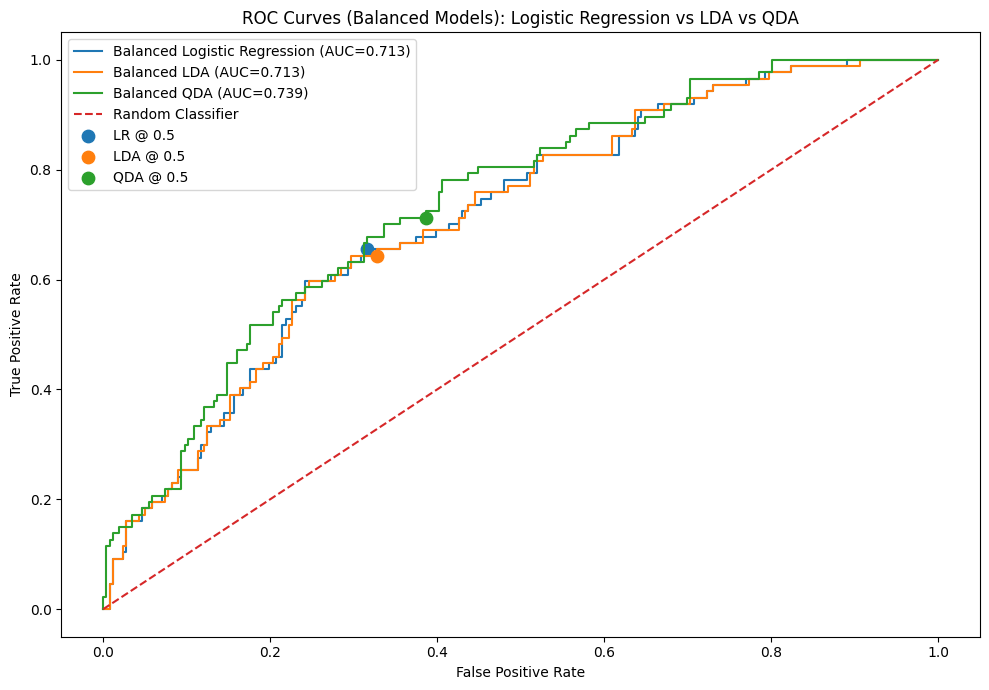

In [48]:
### Balanced multivariate logistic regression ###
probs_lr = logreg.predict_proba(X_test_std)[:, 1]  
fpr_lr, tpr_lr, thr_lr = metrics.roc_curve(y_test, probs_lr)
auc_lr = metrics.auc(fpr_lr, tpr_lr)

### Balanced multivariate LDA ###
probs_lda = lda.predict_proba(X_test_std)[:, 1]     
fpr_lda, tpr_lda, thr_lda = metrics.roc_curve(y_test, probs_lda)
auc_lda = metrics.auc(fpr_lda, tpr_lda)

### Balanced multivariate QDA ###
probs_qda = qda_3.predict_proba(X_test_std)[:, 1]
fpr_qda, tpr_qda, thr_qda = metrics.roc_curve(y_test, probs_qda)
auc_qda = metrics.auc(fpr_qda, tpr_qda)

# helper function to point on the ROC closest to threshold = 0.5
def roc_point_at_threshold(fpr, tpr, thr, target=0.5):
    idx = np.argmin(np.abs(thr - target))
    return fpr[idx], tpr[idx]

pt_lr  = roc_point_at_threshold(fpr_lr,  tpr_lr,  thr_lr,  0.5)
pt_lda = roc_point_at_threshold(fpr_lda, tpr_lda, thr_lda, 0.5)
pt_qda = roc_point_at_threshold(fpr_qda, tpr_qda, thr_qda, 0.5)

# plot curves
plt.figure(figsize=(10,7))
plt.plot(fpr_lr,  tpr_lr,  label=f"Balanced Logistic Regression (AUC={auc_lr:.3f})")
plt.plot(fpr_lda, tpr_lda, label=f"Balanced LDA (AUC={auc_lda:.3f})")
plt.plot(fpr_qda, tpr_qda, label=f"Balanced QDA (AUC={auc_qda:.3f})")
plt.plot([0,1], [0,1], linestyle="--", label="Random Classifier")

# add the 0.5 threshold markers
plt.scatter(pt_lr[0],  pt_lr[1],  marker="o", s=80, label="LR @ 0.5")
plt.scatter(pt_lda[0], pt_lda[1], marker="o", s=80, label="LDA @ 0.5")
plt.scatter(pt_qda[0], pt_qda[1], marker="o", s=80, label="QDA @ 0.5")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves (Balanced Models): Logistic Regression vs LDA vs QDA")
plt.legend()
plt.tight_layout()
plt.show()


## Conclusion

After training and evaluating Logistic Regression, LDA, and QDA on the wildfire satellite dataset, **QDA is the recommended classifier** for this task:

| Metric | Logistic Regression | LDA | QDA |
|---|---|---|---|
| **AUC** | Good | Good | **Highest** |
| **Sensitivity** | Moderate | Moderate | **Highest** |
| **Specificity** | Highest | High | Lower |

**Why QDA?**
- **Highest AUC** — QDA has the best overall discriminative power across all classification thresholds.
- **Highest sensitivity** — QDA catches the most actual fires, which is the most critical metric for wildfire detection. A missed fire (false negative) has far more severe consequences than a false alarm (false positive).
- The trade-off of slightly lower specificity is acceptable in this domain — emergency services would prefer to investigate a few false alarms rather than miss a real wildfire.
- QDA's flexibility in modeling separate class covariances is justified by the data: the Fire and No Fire classes genuinely exhibit different variance structures.

**Key takeaways from this analysis:**
1. Class imbalance must be addressed (via SMOTE or class weighting) — unbalanced models default to predicting the majority class.
2. Multivariate models consistently outperform single-feature models, confirming that NDVI, LST, and THERMAL_ANOMALIES each contribute independent predictive signal.
3. The choice between LDA and QDA depends on whether classes share the same covariance structure — in this dataset, they don't, giving QDA an edge.

In [ ]:
from matplotlib.gridspec import GridSpec
from io import BytesIO

# Temporarily replace plt.show so the helper function doesn't display/close its figure
_original_show = plt.show
plt.show = lambda *a, **kw: None

# ── Left panel: QDA decision boundary (NDVI vs LST) ──
qda_thumb = QuadraticDiscriminantAnalysis(store_covariance=True)
qda_thumb.fit(os_X_train_std[['NDVI', 'LST']], os_y_train)

plot_da_contours_custom_features(
    qda_thumb, os_X_train_std, 'NDVI', 'LST', class_labels=['No Fire', 'Fire']
)
fig_qda = plt.gcf()
buf_qda = BytesIO()
fig_qda.savefig(buf_qda, format='png', dpi=150, bbox_inches='tight')
plt.close(fig_qda)
buf_qda.seek(0)

plt.show = _original_show  # restore

# ── Right panel: ROC model comparison ──
fig_roc, ax_roc = plt.subplots(figsize=(10, 7))
ax_roc.plot(fpr_lr,  tpr_lr,  label=f"Logistic Regression (AUC={auc_lr:.3f})")
ax_roc.plot(fpr_lda, tpr_lda, label=f"LDA (AUC={auc_lda:.3f})")
ax_roc.plot(fpr_qda, tpr_qda, label=f"QDA (AUC={auc_qda:.3f})")
ax_roc.plot([0, 1], [0, 1], 'r--', label="Random Classifier")
ax_roc.scatter(*pt_lr,  s=80, zorder=5, label="LR @ 0.5")
ax_roc.scatter(*pt_lda, s=80, zorder=5, label="LDA @ 0.5")
ax_roc.scatter(*pt_qda, s=80, zorder=5, label="QDA @ 0.5")
ax_roc.set_xlabel("False Positive Rate")
ax_roc.set_ylabel("True Positive Rate")
ax_roc.set_title("ROC Curves (Balanced Models)")
ax_roc.legend(fontsize=9)
fig_roc.tight_layout()
buf_roc = BytesIO()
fig_roc.savefig(buf_roc, format='png', dpi=150, bbox_inches='tight')
plt.close(fig_roc)
buf_roc.seek(0)

# ── Compose thumbnail ──
img_qda = plt.imread(buf_qda)
img_roc = plt.imread(buf_roc)

fig = plt.figure(figsize=(10, 18), facecolor='#080807')
gs = GridSpec(
    2, 1, 
    figure=fig, 
    hspace=0.08, 
    left=0.02, 
    right=0.98, 
    top=0.93, 
    bottom=0.02)

ax1 = fig.add_subplot(gs[0, 0])
ax1.imshow(img_qda)
ax1.axis('off')

ax2 = fig.add_subplot(gs[1, 0])
ax2.imshow(img_roc)
ax2.axis('off')

fig.suptitle(
    'Wildfire Detection from Satellite Imagery',
    fontsize=28, fontweight='bold', color='#d1d1c7', y=0.97,
)
fig.text(
    0.5, 0.945, 'QDA Classification Boundary  ·  ROC Model Comparison',
    ha='center', fontsize=14, color='#a29e9a',
)

plt.show()

RuntimeError: No image/png output found in cell 113. Run the notebook first so plots are rendered.